In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [136]:
df = pd.read_csv("Housing.csv")


In [190]:
print("\nDataset Overview:")
print(df.head())
print(df.info())


Dataset Overview:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1    

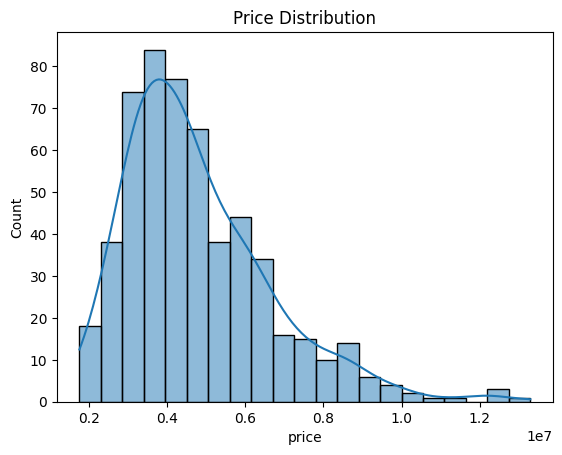

In [191]:
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

In [192]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_cols] = df[binary_cols].apply(lambda x: x.map({'yes': 1, 'no': 0}))


In [195]:
X = df.drop(columns='price')
y = df['price']

In [196]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=42
)

In [197]:
rf_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

In [198]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20]
}

In [199]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)


Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 200}


In [200]:
y_pred = best_model.predict(X_test)

print("\nModel Performance:")
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))



Model Performance:
R2 Score: 0.49315087972080796
MSE: 2354975393781.23



Top Features:
                            Feature  Importance
0                              area    0.546576
2                         bathrooms    0.173625
9                           parking    0.077833
3                           stories    0.072850
1                          bedrooms    0.058874
12     furnishingstatus_unfurnished    0.045809
11  furnishingstatus_semi-furnished    0.024432
4                          mainroad    0.000000
5                         guestroom    0.000000
8                   airconditioning    0.000000


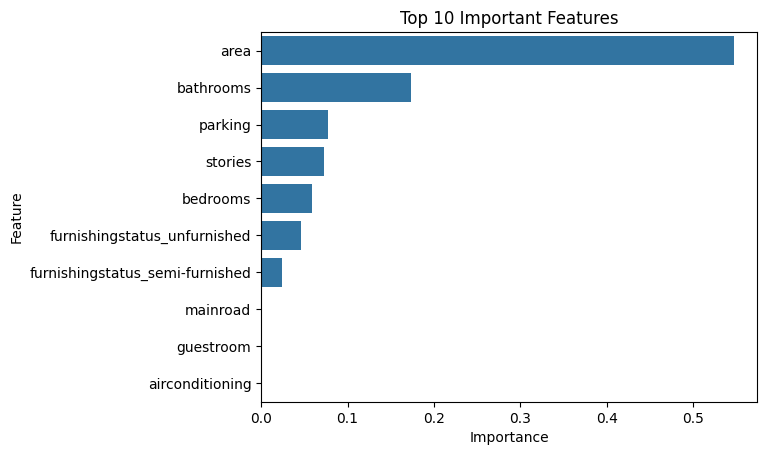

In [201]:
rf_model = best_model.named_steps['model']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:")
print(importance_df.head(10))

sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()


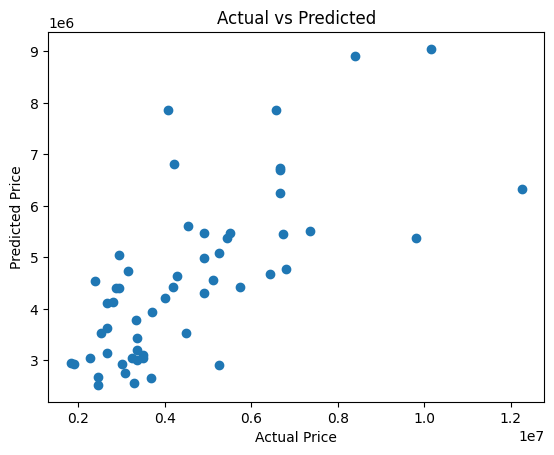

In [202]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [203]:
joblib.dump(best_model, "house_price_model.pkl")


['house_price_model.pkl']